# Garbage Image Classification — CNN with TensorFlow

## Overview
This notebook builds and evaluates a convolutional neural network (CNN) to classify images of garbage into four material categories: brown glass, green glass, white glass, and plastic.

The original baseline model achieved a validation F1 of 0.873. This project rebuilds the pipeline with proper data augmentation, a corrected train/validation split, and integer-keyed class weights - conditions designed to give a more reliable estimate of real-world performance. The revised model achieves 0.8503 under these conditions.

**Final Result:** Validation F1 score of 0.8503 (saved best model weights)

## Dataset
Images sourced from the [Garbage Classification dataset on Kaggle](https://www.kaggle.com/datasets/mostafaabla/garbage-classification) by Mostafa Abla.

## Approach
1. Data preparation and preprocessing (resizing, normalisation, class balancing)
2. Data augmentation via `ImageDataGenerator` (rotation, zoom, flipping, shear) — applied during training only
3. CNN architecture with batch normalisation and L2 regularisation
4. Training with early stopping, learning rate reduction, and model checkpointing
5. Evaluation via F1 score, confusion matrix, and per-class classification report

## Environment
Built and trained in Google Colab using a GPU (L4) runtime.

In [1]:
# Run this only in Google Colab
!pip install tensorflow matplotlib numpy scikit-learn

## Imports

In [2]:
# Core Libraries
import os
import shutil
import random
import zipfile

# Numerical/Scientific
import numpy as np

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Activation, Dropout,
    GlobalAveragePooling2D, Dense, Input
)
from tensorflow.keras.preprocessing.image import (
    load_img, img_to_array, save_img, ImageDataGenerator
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Scikit-learn
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

# Set global seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.__version__

'2.19.0'

## Constants

In [3]:
TARGET_HEIGHT = 128
TARGET_WIDTH  = 128
BATCH_SIZE    = 32
EPOCHS        = 100  # EarlyStopping will halt training before this

## Loading Data from Google Drive
Mount your Google Drive and unzip the dataset. Download the garbage classification dataset named `archive.zip` from [Kaggle](https://www.kaggle.com/datasets/mostafaabla/garbage-classification) to your Drive first, then update `ZIP_PATH` below if needed.

In [4]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Update this path if your zip is stored elsewhere in Drive
ZIP_PATH = '/content/drive/MyDrive/archive.zip'
DIR_PATH = os.path.abspath("garbage_classification")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall('/content')

print("Dataset extracted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully.


## Removing Unnecessary Classes
We keep only the four glass and plastic categories relevant to this project.

In [5]:
folders_to_keep = [
    f for f in os.listdir(DIR_PATH)
    if 'glass' in f or 'plastic' in f
]

for folder in os.listdir(DIR_PATH):
    if folder not in folders_to_keep:
        shutil.rmtree(os.path.join(DIR_PATH, folder))

print("Kept classes:", os.listdir(DIR_PATH))

Kept classes: ['plastic', 'green-glass', 'white-glass', 'brown-glass']


## Data Preparation & Pre-processing
Resize all images to a consistent target size and save to a new directory.
The generators (below) will handle normalisation and augmentation at training time.

In [6]:
NEW_DIR_PATH = os.path.abspath('new_images')

if os.path.exists(NEW_DIR_PATH):
    shutil.rmtree(NEW_DIR_PATH)
    print("Cleared existing new_images directory")

def preprocess_and_save(img_path, save_path, target_height=TARGET_HEIGHT, target_width=TARGET_WIDTH):
    """Load, resize to target dimensions, and save an image."""
    img = load_img(img_path, target_size=(target_height, target_width))
    save_img(save_path, img_to_array(img))

for folder in folders_to_keep:
    src_folder  = os.path.join(DIR_PATH, folder)
    dest_folder = os.path.join(NEW_DIR_PATH, folder)
    os.makedirs(dest_folder, exist_ok=True)

    for fname in os.listdir(src_folder):
        preprocess_and_save(
            os.path.join(src_folder, fname),
            os.path.join(dest_folder, fname)
        )

print("Pre-processing complete.")
for folder in folders_to_keep:
    n = len(os.listdir(os.path.join(NEW_DIR_PATH, folder)))
    print(f"  {folder}: {n} images")

Cleared existing new_images directory
Pre-processing complete.
  plastic: 865 images
  green-glass: 629 images
  white-glass: 775 images
  brown-glass: 607 images


### Class Imbalance
Class weights are computed using inverse frequency: minority classes receive higher weights so the loss function penalises misclassifying them more heavily. This is preferable to oversampling for small datasets as it avoids duplicating images.

In [7]:
class_count_dict = {
    folder: len(os.listdir(os.path.join(NEW_DIR_PATH, folder)))
    for folder in folders_to_keep
}

total       = sum(class_count_dict.values())
num_classes = len(class_count_dict)

# Temporary string-keyed weights — remapped to integer keys after generators are built
_class_weights_str = {
    cls: total / (num_classes * count)
    for cls, count in class_count_dict.items()
}

print("Class counts and raw weights:")
for cls, count in class_count_dict.items():
    print(f"  {cls}: {count} images  |  weight: {_class_weights_str[cls]:.3f}")

Class counts and raw weights:
  plastic: 865 images  |  weight: 0.831
  green-glass: 629 images  |  weight: 1.143
  white-glass: 775 images  |  weight: 0.928
  brown-glass: 607 images  |  weight: 1.185


## Data Generators
A single ImageDataGenerator instance handles both training and validation subsets. Using one instance is important as Keras applies augmentation based on the subset parameter at the flow_from_directory level, so the validation subset receives only rescaling regardless of the augmentation parameters defined on the generator.

In [8]:
# Single generator instance — augmentation only applied to training subset
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=15,
    brightness_range=[0.7, 1.3],
    channel_shift_range=20.0,
    fill_mode="nearest"
)

train_generator = datagen.flow_from_directory(
    NEW_DIR_PATH,
    target_size=(TARGET_HEIGHT, TARGET_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    NEW_DIR_PATH,
    target_size=(TARGET_HEIGHT, TARGET_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Map class names → integer indices for class_weight dict and display
class_indices = train_generator.class_indices          # e.g. {'brown_glass': 0, ...}
index_to_name = {v: k for k, v in class_indices.items()}

# Remap class weights to integer keys as required by Keras
class_weights = {
    class_indices[cls]: weight
    for cls, weight in _class_weights_str.items()
}

print("Class indices:", class_indices)
print("Class weights:", {index_to_name[k]: round(v, 3) for k, v in class_weights.items()})

Found 2015 images belonging to 4 classes.
Found 861 images belonging to 4 classes.
Class indices: {'brown-glass': 0, 'green-glass': 1, 'plastic': 2, 'white-glass': 3}
Class weights: {'plastic': 0.831, 'green-glass': 1.143, 'white-glass': 0.928, 'brown-glass': 1.185}


## Custom Metrics
Keras does not include F1 natively, so we implement it from precision and recall.

In [9]:
def recall_m(y_true, y_pred):
    true_positives  = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())

def precision_m(y_true, y_pred):
    true_positives     = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    return true_positives / (predicted_positives + K.epsilon())

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall    = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

## Callbacks
Three callbacks work in combination: EarlyStopping monitors validation loss to decide when to halt training; ReduceLROnPlateau halves the learning rate when validation loss plateaus, allowing finer optimisation; ModelCheckpoint saves the weights from the epoch with the highest validation F1, which is the metric we care most about at evaluation time.

In [10]:
def early_stop(patience=5):
    return EarlyStopping(
        monitor='val_loss',
        patience=patience,
        verbose=1,
        restore_best_weights=False  # Weights loaded from checkpoint in evaluation cell
    )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_f1_m',
    save_best_only=True,
    mode='max'  # Save the highest validation f1 metric
)

## Model Architecture
Five convolutional blocks with doubling filter counts (16 to 256).
Each block follows the Conv2D → BatchNorm → ReLU → Pool pattern.
L2 regularisation and dropout are applied to combat overfitting.

Dropout rates increase deeper in the network (0.3 to 0.4 to 0.5) where feature representations are more abstract and overfitting risk is higher. GlobalAveragePooling2D is used instead of Flatten to reduce parameter count and improve generalisation.

In [11]:
l2_reg = tf.keras.regularizers.l2(0.0005)

model = Sequential([
    Input(shape=(TARGET_HEIGHT, TARGET_WIDTH, 3)),

    # Block 1
    Conv2D(16, (3,3), kernel_regularizer=l2_reg, padding="same"),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),

    # Block 2
    Conv2D(32, (3,3), kernel_regularizer=l2_reg, padding="same"),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),

    # Block 3
    Conv2D(64, (3,3), kernel_regularizer=l2_reg, padding="same"),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),

    # Block 4
    Conv2D(128, (3,3), kernel_regularizer=l2_reg, padding="same"),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.3),

    # Block 5
    Conv2D(256, (3,3), kernel_regularizer=l2_reg, padding="same"),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_m]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 428,004 (1.63 MB)

 Trainable params: 427,012 (1.63 MB)

 Non-trainable params: 992 (3.88 KB)

## Training

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop(patience=10), reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 48s 525ms/step - f1_m: 0.6610 - loss: 0.8914 - val_f1_m: 0.2512 - val_loss: 1.9297 - learning_rate: 0.0010
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 290ms/step - f1_m: 0.7483 - loss: 0.7362 - val_f1_m: 0.2722 - val_loss: 2.5199 - learning_rate: 0.0010
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 277ms/step - f1_m: 0.7564 - loss: 0.7135 - val_f1_m: 0.2941 - val_loss: 2.2655 - learning_rate: 0.0010
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 286ms/step - f1_m: 0.7788 - loss: 0.6456 - val_f1_m: 0.4162 - val_loss: 2.1152 - learning_rate: 0.0010
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - f1_m: 0.7903 - loss: 0.6339 - val_f1_m: 0.5413 - val_loss: 1.4036 - learning_rate: 0.0010
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - f1_m: 0.7948 - loss: 0.5929 - val_f1_m: 0.5965 - val_loss: 1.1412 - learning_rate: 0.0010
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 277ms/step - f1_m: 0.8013 - loss: 0.5807 - val_f1_m: 0.7369 - val_loss: 0.7361 - 

## Results
The final epoch val F1 of 0.8333 reflects the last epoch's performance, while the saved model's 0.8503 represents the peak validation F1 achieved during training (epoch 82). The approximately 6 point gap between train F1 (~0.91) and val F1 (0.85) indicates moderate overfitting that proved resistant to further regularisation — consistent with a dataset of this size. Transfer learning would be the natural next step to push performance further.

### F1 History

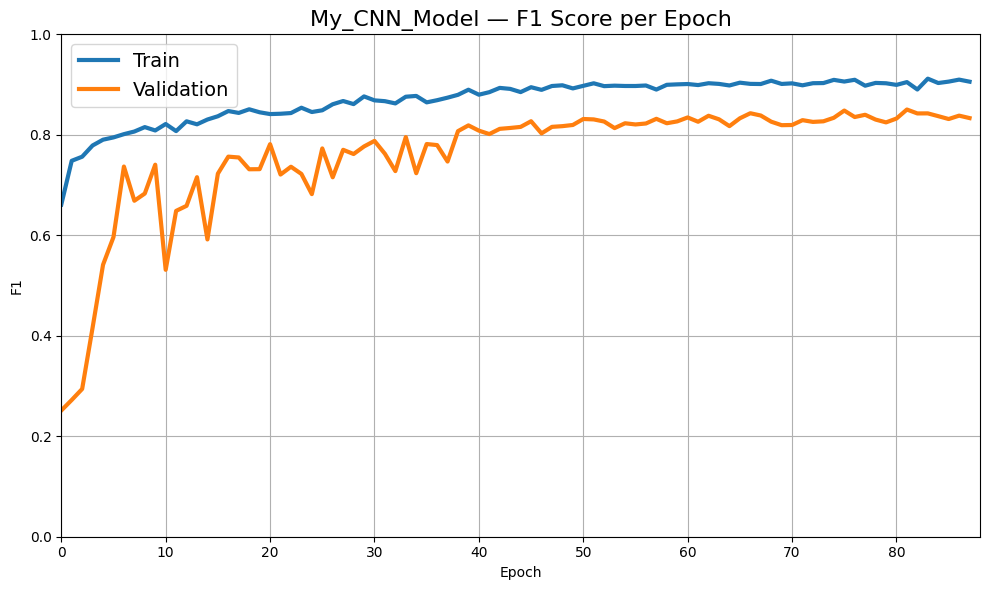

Final train F1:      0.906
Final validation F1: 0.833


In [13]:
def plot_f1_history(model_name, run_hist):
    plt.figure(figsize=(10, 6))
    plt.plot(run_hist.history['f1_m'],     linewidth=3, label='Train')
    plt.plot(run_hist.history['val_f1_m'], linewidth=3, label='Validation')
    plt.title(model_name + ' — F1 Score per Epoch', fontsize=16)
    plt.ylabel('F1')
    plt.xlabel('Epoch')
    plt.ylim(0, 1)
    plt.xlim(0, len(run_hist.history['f1_m']))
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(model_name + '_F1.jpg')  # Save before show() — show() clears the figure
    plt.show()

    print(f"Final train F1:      {run_hist.history['f1_m'][-1]:.3f}")
    print(f"Final validation F1: {run_hist.history['val_f1_m'][-1]:.3f}")

plot_f1_history("My_CNN_Model", history)

### Confusion Matrix

In [14]:
def make_confusion_matrix(model_name, y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    ax = plt.subplot()
    sns.heatmap(cm, cmap="Blues", annot=True, square=True, fmt="d",
                annot_kws={"fontsize": 16})
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('Actual', fontsize=14)
    ax.xaxis.set_ticklabels(class_names, fontsize=13, rotation=30)
    ax.yaxis.set_ticklabels(class_names, fontsize=13, rotation=0)
    plt.title(model_name + '\nConfusion Matrix', fontsize=16, loc='left', pad=12)
    plt.tight_layout()
    plt.savefig(model_name + '_confusion.jpg')  # Save before show()
    plt.show()

### Predictions & Evaluation

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 240ms/step


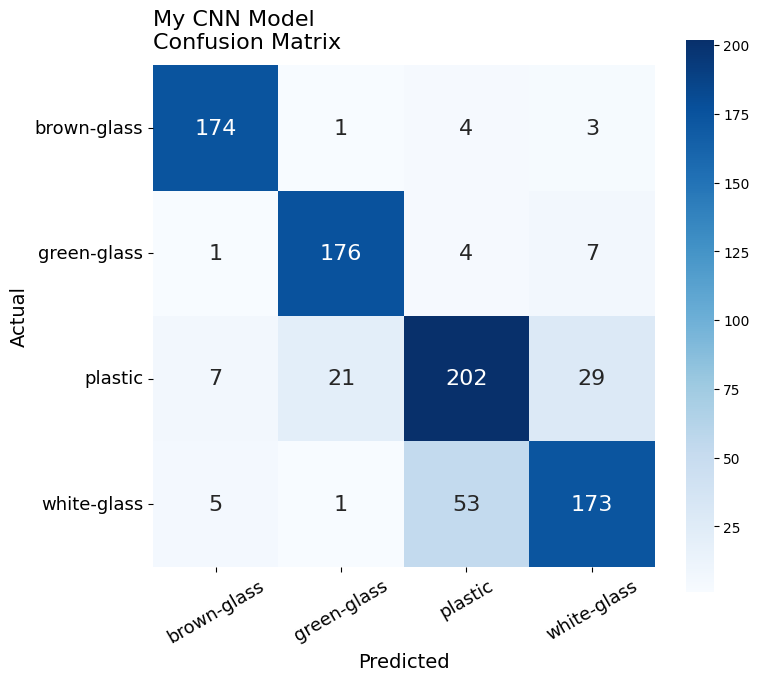


Classification Report:
              precision    recall  f1-score   support

 brown-glass       0.93      0.96      0.94       182
 green-glass       0.88      0.94      0.91       188
     plastic       0.77      0.78      0.77       259
 white-glass       0.82      0.75      0.78       232

    accuracy                           0.84       861
   macro avg       0.85      0.85      0.85       861
weighted avg       0.84      0.84      0.84       861

Overall Accuracy: 0.8420


In [15]:
# Load best saved weights before evaluating
model.load_weights('best_model.keras')

# Predict on the validation set (shuffle=False ensures order matches labels)
predictions = model.predict(val_generator)
y_pred      = np.argmax(predictions, axis=1)
y_true      = val_generator.classes

class_names = [index_to_name[i] for i in range(len(class_indices))]

make_confusion_matrix("My CNN Model", y_true, y_pred, class_names)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")

### Misclassified Examples

/tmp/ipykernel_56867/1200305220.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


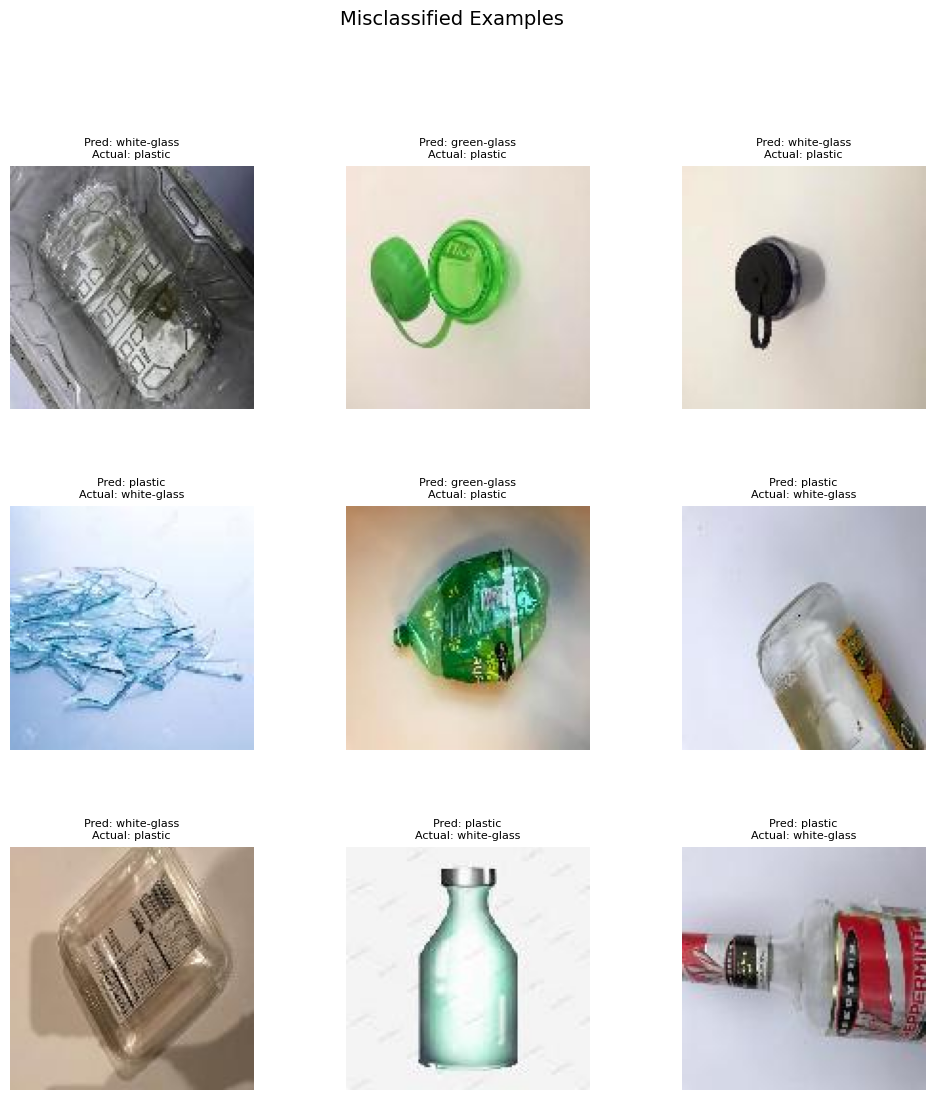

In [16]:
def show_misclassified(y_true, y_pred, filenames, class_names, base_dir, n=9):
    """
    Display a random sample of misclassified images.

    Args:
        y_true      : array of true class indices
        y_pred      : array of predicted class indices
        filenames   : list of relative file paths from the generator (generator.filenames)
        class_names : ordered list of class name strings
        base_dir    : root directory of the image data (NEW_DIR_PATH)
        n           : number of examples to display
    """
    misclassified = [i for i in range(len(y_pred)) if y_pred[i] != y_true[i]]
    if len(misclassified) < n:
        n = len(misclassified)
    sample = np.random.choice(misclassified, size=n, replace=False)

    fig = plt.figure(figsize=(12, 12))
    gs  = gridspec.GridSpec(3, 3)
    gs.update(wspace=0.3, hspace=0.4)

    for i, idx in enumerate(sample):
        ax = plt.subplot(gs[i])
        ax.axis("off")
        ax.set_title(
            f"Pred: {class_names[y_pred[idx]]}\nActual: {class_names[y_true[idx]]}",
            fontsize=8
        )
        img_path = os.path.join(base_dir, filenames[idx])
        plt.imshow(load_img(img_path))

    plt.suptitle("Misclassified Examples", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

show_misclassified(
    y_true      = y_true,
    y_pred      = y_pred,
    filenames   = val_generator.filenames,
    class_names = class_names,
    base_dir    = NEW_DIR_PATH
)